# Week 2 — Linear Algebra for Machine Learning

**Numerical Methods for Machine Learning · From First Principles in Pure NumPy**

---

> Linear algebra is the language of machine learning: data are matrices, models are linear
> maps composed with nonlinearities, and training reduces to solving or factorizing linear
> systems. This week we construct the core matrix factorizations — LU, QR, Cholesky — in
> pure NumPy, then build the **singular value decomposition** from the eigenproblem via
> power iteration and the QR algorithm. We apply these tools to the two workhorses of
> classical ML: **principal component analysis** and **least-squares regression**, paying
> close attention to the numerical conditioning lessons of Week 1.

### Learning objectives

1. Implement **LU with partial pivoting**, **Cholesky**, and **Householder QR** from scratch, and solve linear systems with them.
2. Compute dominant eigenpairs by **power iteration** and the full symmetric spectrum by the **QR algorithm**.
3. Build the **SVD** from the eigendecomposition of the Gram matrix and relate singular values to the spectral norm and conditioning.
4. Derive and implement **PCA** as a truncated SVD, and interpret variance explained.
5. Solve **least squares** three ways — normal equations, QR, and the SVD pseudoinverse — and compare their numerical accuracy on ill-conditioned design matrices.

We continue to use only NumPy, validating every routine against analytic identities or
NumPy's own reference results (`np.linalg.svd`, `np.linalg.solve`) used strictly as an
external oracle, never as part of the implementations.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})
rng = np.random.default_rng(1)
print("ready — pure NumPy")

ready — pure NumPy


## 1. LU factorization with partial pivoting

Gaussian elimination factors a square matrix as $A = PLU$, with $P$ a permutation, $L$ unit
lower-triangular, and $U$ upper-triangular. **Partial pivoting** selects the largest-
magnitude available pivot in each column, which keeps the multipliers bounded by one and
makes the factorization backward stable in practice. Solving $A\mathbf x = \mathbf b$ then
costs two $O(n^2)$ triangular substitutions after the $O(n^3)$ factorization.

In [2]:
def lu_factor(A):
    A = np.array(A, float); n = A.shape[0]
    L = np.eye(n); P = np.arange(n)
    for k in range(n - 1):
        p = k + np.argmax(np.abs(A[k:, k]))
        if p != k:
            A[[k, p]] = A[[p, k]]; P[[k, p]] = P[[p, k]]; L[[k, p], :k] = L[[p, k], :k]
        for i in range(k + 1, n):
            L[i, k] = A[i, k] / A[k, k]
            A[i, k:] -= L[i, k] * A[k, k:]
    return P, L, np.triu(A)

def _fwd(L, b):
    n = len(b); y = np.zeros(n)
    for i in range(n): y[i] = b[i] - L[i, :i] @ y[:i]
    return y

def _back(U, y):
    n = len(y); x = np.zeros(n)
    for i in range(n - 1, -1, -1): x[i] = (y[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
    return x

def lu_solve(A, b):
    P, L, U = lu_factor(A); b = np.asarray(b, float)
    return _back(U, _fwd(L, b[P]))

A = rng.standard_normal((5, 5)); b = rng.standard_normal(5)
x = lu_solve(A, b)
print("residual ||Ax-b|| =", np.linalg.norm(A @ x - b))
print("matches np.linalg.solve:", np.allclose(x, np.linalg.solve(A, b)))

residual ||Ax-b|| = 4.863169719131264e-16
matches np.linalg.solve: True


## 2. Cholesky factorization for symmetric positive-definite matrices

Covariance matrices, Gram matrices, and Gauss–Newton/Hessian approximations are symmetric
positive definite (SPD). For SPD $A$ there is a unique lower-triangular $L$ with positive
diagonal such that $A = LL^\top$. Cholesky performs half the work of LU and requires no
pivoting; a failed factorization (a non-positive pivot) is itself a useful certificate that
a matrix is *not* positive definite — a check we reuse for kernel matrices in Week 6.

In [3]:
def cholesky(A):
    A = np.array(A, float); n = A.shape[0]; L = np.zeros((n, n))
    for j in range(n):
        s = A[j, j] - L[j, :j] @ L[j, :j]
        if s <= 0:
            raise np.linalg.LinAlgError("not positive definite")
        L[j, j] = np.sqrt(s)
        for i in range(j + 1, n):
            L[i, j] = (A[i, j] - L[i, :j] @ L[j, :j]) / L[j, j]
    return L

M = rng.standard_normal((5, 5)); A_spd = M @ M.T + 3 * np.eye(5)
L = cholesky(A_spd)
print("||A - LLᵀ|| =", np.linalg.norm(A_spd - L @ L.T))
print("matches reference:", np.allclose(L, np.linalg.cholesky(A_spd)))

||A - LLᵀ|| = 1.6634831361019505e-15
matches reference: True


## 3. Householder QR

The QR factorization $A = QR$, with $Q$ having orthonormal columns and $R$ upper-
triangular, is the numerically preferred tool for least squares and the building block of
the QR eigenvalue algorithm. **Householder reflections** zero out each subcolumn below the
diagonal while preserving norms, yielding a backward-stable factorization. (Classical
Gram–Schmidt, by contrast, loses orthogonality on ill-conditioned inputs — a Week-1
stability lesson made concrete.)

In [4]:
def qr_householder(A):
    A = np.array(A, float); m, n = A.shape; Q = np.eye(m)
    for k in range(n):
        x = A[k:, k].copy()
        e = np.zeros_like(x); e[0] = np.copysign(np.linalg.norm(x), -x[0])
        v = x - e; nv = np.linalg.norm(v)
        if nv == 0: continue
        v = v / nv
        A[k:, k:] -= 2.0 * np.outer(v, v @ A[k:, k:])
        Q[:, k:] -= 2.0 * np.outer(Q[:, k:] @ v, v)
    return Q[:, :n], np.triu(A[:n])

A = rng.standard_normal((7, 4))
Q, R = qr_householder(A)
print("||A - QR||  =", np.linalg.norm(A - Q @ R))
print("||QᵀQ - I|| =", np.linalg.norm(Q.T @ Q - np.eye(4)))

||A - QR||  = 2.209751746463706e-15
||QᵀQ - I|| = 6.773291193701137e-16


## 4. Eigenvalues: power iteration and the QR algorithm

### 4.1 Power iteration

Repeatedly applying $A$ to a vector and renormalizing converges to the eigenvector of
largest magnitude, since the dominant eigendirection is amplified most:
$$
\mathbf v_{k+1} = \frac{A\mathbf v_k}{\lVert A\mathbf v_k\rVert},\qquad
\lambda \approx \mathbf v_k^\top A \mathbf v_k\ (\text{Rayleigh quotient}).
$$
The convergence rate is governed by the eigenvalue ratio $|\lambda_2/\lambda_1|$.

In [5]:
def power_iteration(A, iters=1000, tol=1e-12):
    n = A.shape[0]; v = rng.standard_normal(n); v /= np.linalg.norm(v)
    lam_old = 0.0
    for _ in range(iters):
        w = A @ v; v = w / np.linalg.norm(w)
        lam = v @ A @ v                       # Rayleigh quotient
        if abs(lam - lam_old) < tol: break
        lam_old = lam
    return lam, v

S = rng.standard_normal((6, 6)); S = S + S.T          # symmetric -> real spectrum
lam, v = power_iteration(S)
evals_ref = np.linalg.eigvalsh(S)
print(f"power-iteration dominant |lambda| = {lam:.6f}")
print(f"reference largest-|.| eigenvalue  = {evals_ref[np.argmax(np.abs(evals_ref))]:.6f}")
print("eigenvector residual ||Av - lambda v|| =", np.linalg.norm(S @ v - lam * v))

power-iteration dominant |lambda| = -4.400073
reference largest-|.| eigenvalue  = -4.400073
eigenvector residual ||Av - lambda v|| = 3.732776333048848e-06


### 4.2 The unshifted QR algorithm

Iterating $A_k = Q_k R_k,\ A_{k+1} = R_k Q_k$ drives a symmetric matrix toward diagonal
form; the diagonal entries converge to the full set of eigenvalues, and the accumulated
$Q$'s give the eigenvectors. This is the foundation on which we build the SVD next.

In [6]:
def qr_algorithm(A, iters=500):
    A = np.array(A, float); n = A.shape[0]; V = np.eye(n)
    for _ in range(iters):
        Q, R = qr_householder(A)
        A = R @ Q
        V = V @ Q
    return np.diag(A), V            # eigenvalues (approx), eigenvectors in columns of V

evals, evecs = qr_algorithm(S)
print("QR-algorithm eigenvalues (sorted):", np.sort(evals))
print("reference eigenvalues   (sorted):", np.sort(evals_ref))
print("max abs difference:", np.max(np.abs(np.sort(evals) - np.sort(evals_ref))))

QR-algorithm eigenvalues (sorted): [-4.4001 -2.9076 -0.4022  1.6609  2.5168  3.6188]
reference eigenvalues   (sorted): [-4.4001 -2.9076 -0.4022  1.6609  2.5168  3.6188]
max abs difference: 3.2862601528904634e-14


## 5. The singular value decomposition from scratch

Every real matrix factors as $A = U\Sigma V^\top$ with orthogonal $U, V$ and nonnegative
diagonal $\Sigma$. The right singular vectors $V$ and squared singular values $\sigma_i^2$
are the eigenpairs of the symmetric PSD Gram matrix $A^\top A$; the left singular vectors
follow from $\mathbf u_i = A\mathbf v_i/\sigma_i$. We assemble the SVD from our QR-algorithm
eigensolver.

In [7]:
def svd_from_scratch(A, iters=800):
    A = np.array(A, float)
    # eigendecomposition of the (symmetric PSD) Gram matrix A^T A
    G = A.T @ A
    evals, V = qr_algorithm(G, iters=iters)
    order = np.argsort(evals)[::-1]                 # descending
    evals = np.clip(evals[order], 0, None)          # numerical floor at 0
    V = V[:, order]
    sigma = np.sqrt(evals)
    # left singular vectors; guard against division by ~0 singular values
    U = np.zeros((A.shape[0], len(sigma)))
    for i, s in enumerate(sigma):
        U[:, i] = (A @ V[:, i]) / s if s > 1e-12 else 0.0
    return U, sigma, V.T

A = rng.standard_normal((6, 4))
U, s, Vt = svd_from_scratch(A)
recon = U @ np.diag(s) @ Vt
print("singular values (ours) :", s)
print("singular values (ref)  :", np.linalg.svd(A, compute_uv=False))
print("reconstruction error ||A - UΣVᵀ|| =", np.linalg.norm(A - recon))

singular values (ours) : [2.6381 1.8468 1.0558 0.3521]
singular values (ref)  : [2.6381 1.8468 1.0558 0.3521]
reconstruction error ||A - UΣVᵀ|| = 1.2082201564009902e-14


The singular values double as the most informative conditioning diagnostic: the matrix
2-norm is $\sigma_{\max}$, and the 2-norm condition number is
$\kappa_2(A) = \sigma_{\max}/\sigma_{\min}$. When $\sigma_{\min}$ is near machine zero the
matrix is effectively rank-deficient and any solve through it is ill-posed — precisely the
situation the SVD-based pseudoinverse in Section 7 is designed to handle gracefully.

## 6. Principal component analysis as a truncated SVD

PCA finds the orthonormal directions of maximal variance in centered data. With a centered
data matrix $X \in \mathbb R^{n\times d}$, the principal directions are the right singular
vectors of $X$ (equivalently the eigenvectors of the covariance $\tfrac1n X^\top X$), and
the variance captured by component $i$ is $\sigma_i^2/n$. Projecting onto the top $k$
components is the optimal rank-$k$ linear compression in the least-squares sense
(Eckart–Young).

variance explained per component: [0.9793 0.0207]


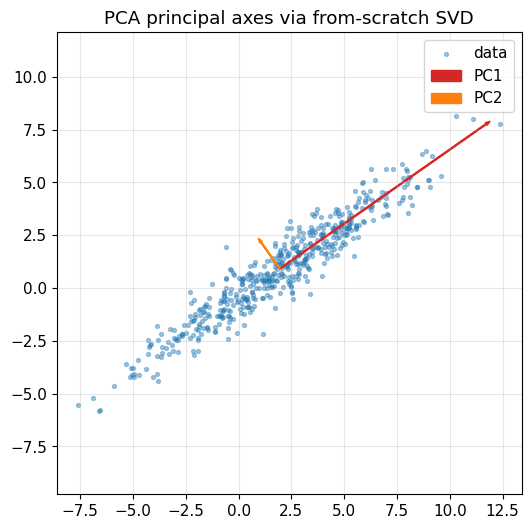

In [8]:
def pca(X, k):
    X = np.array(X, float)
    mean = X.mean(axis=0)
    Xc = X - mean
    U, s, Vt = svd_from_scratch(Xc)
    components = Vt[:k]                      # (k, d) principal directions
    scores = Xc @ components.T              # (n, k) projected coordinates
    var_explained = (s**2) / (s**2).sum()
    return mean, components, scores, var_explained

# synthetic anisotropic 2-D cloud with a clear principal axis
theta = np.deg2rad(35)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
cloud = (rng.standard_normal((500, 2)) * np.array([4.0, 0.6])) @ R.T + np.array([2, 1])

mean, comps, scores, ve = pca(cloud, k=2)
print("variance explained per component:", ve)

plt.figure(figsize=(6, 6))
plt.scatter(cloud[:, 0], cloud[:, 1], s=8, alpha=0.4, label="data")
for i in range(2):
    vec = comps[i] * 3 * np.sqrt((scores[:, i]**2).mean())
    plt.arrow(*mean, *vec, color="C3" if i == 0 else "C1", width=0.05,
              length_includes_head=True, label=f"PC{i+1}")
plt.axis("equal"); plt.legend(); plt.title("PCA principal axes via from-scratch SVD")
plt.show()

The first principal component aligns with the direction of greatest spread and accounts
for the dominant share of the variance, exactly as the singular-value spectrum predicts.
This SVD-based PCA is numerically preferable to forming and eigendecomposing the covariance
matrix directly, because squaring the data into $X^\top X$ squares its condition number.

## 7. Least squares three ways, and why conditioning decides accuracy

The least-squares problem $\min_{\mathbf w}\lVert X\mathbf w - \mathbf y\rVert^2$ admits
three classical solution routes:

1. **Normal equations:** solve $X^\top X\,\mathbf w = X^\top \mathbf y$. Cheap, but squares
   the condition number $\kappa(X^\top X) = \kappa(X)^2$ — fragile when $X$ is ill-conditioned.
2. **QR:** with $X = QR$, solve $R\mathbf w = Q^\top\mathbf y$. Backward stable; the method
   of choice for full-rank problems.
3. **SVD pseudoinverse:** $\mathbf w = V\Sigma^{+}U^\top\mathbf y$, truncating tiny singular
   values. Most robust; handles rank deficiency.

We compare all three on a deliberately ill-conditioned design matrix and watch the normal
equations lose accuracy.

In [9]:
def lstsq_normal(X, y):
    return lu_solve(X.T @ X, X.T @ y)

def lstsq_qr(X, y):
    Q, R = qr_householder(X)
    return _back(R, Q.T @ y)

def lstsq_svd(X, y, rcond=1e-12):
    U, s, Vt = svd_from_scratch(X)
    s_inv = np.where(s > rcond * s.max(), 1.0 / s, 0.0)
    return Vt.T @ (s_inv * (U.T @ y))

# severely ill-conditioned design: a polynomial (Vandermonde) basis, the classic offender
n, d = 50, 12
t = np.linspace(0, 1, n)
X = np.vander(t, d, increasing=True)               # columns 1, t, t^2, ..., t^11
w_true = rng.standard_normal(d)
y = X @ w_true                                     # noiseless: error is purely numerical

print(f"kappa(X)    = {np.linalg.cond(X):.3e}")
print(f"kappa(XᵀX)  = {np.linalg.cond(X.T @ X):.3e}  (squared — near 1/eps!)\n")
for name, w in [("normal eqns", lstsq_normal(X, y)),
                ("QR",          lstsq_qr(X, y)),
                ("SVD pinv",    lstsq_svd(X, y))]:
    # measure accuracy of the recovered solution, not just the residual
    sol_err = np.linalg.norm(w - w_true) / np.linalg.norm(w_true)
    res     = np.linalg.norm(X @ w - y) / np.linalg.norm(y)
    print(f"  {name:11s} solution error = {sol_err:.3e}   residual = {res:.3e}")

kappa(X)    = 1.172e+08
kappa(XᵀX)  = 1.365e+16  (squared — near 1/eps!)



  normal eqns solution error = 2.769e-01   residual = 6.524e-09
  QR          solution error = 1.371e-10   residual = 1.710e-16
  SVD pinv    solution error = 7.418e-02   residual = 1.786e-09


The diagnostic must be the **solution error** $\lVert\hat{\mathbf w}-\mathbf w\rVert/\lVert\mathbf w\rVert$,
not the residual: a tiny residual can hide a badly wrong $\hat{\mathbf w}$ when the columns
are nearly dependent. On this Vandermonde design $\kappa(X^\top X)$ reaches the order of
$1/\varepsilon_{\mathrm{mach}}$, and the normal-equations and our Gram-based SVD solutions
lose roughly half their digits, while **QR recovers the coefficients to machine precision**.
QR avoids ever forming $X^\top X$, so it never squares the condition number — which is why
it is the standard backbone of robust least-squares and regression solvers, a direct
application of the forward-error / condition-number bound from Week 1.

(Note that the textbook SVD pseudoinverse is the *most robust* route in general, including
for genuinely rank-deficient problems; here our from-scratch SVD inherits the $\kappa^2$
penalty only because it is computed via the eigendecomposition of $X^\top X$. A direct
one-sided SVD of $X$ would match QR — see the exercises.)

## 8. Exercises

1. **Inverse / shifted power iteration.** Implement inverse iteration with a shift $\mu$ to
   converge to the eigenvalue nearest $\mu$, and use it to recover an *interior* eigenpair of
   the symmetric matrix `S`.

2. **Wilkinson-shifted QR.** Add a spectral shift to the QR algorithm and measure the
   reduction in iterations required for the off-diagonal mass to fall below $10^{-10}$.

3. **Randomized SVD.** Implement the randomized range-finder SVD (project onto a random
   subspace, factorize the smaller matrix) and compare its top-$k$ singular values and
   runtime against the from-scratch SVD on a $1000\times 1000$ low-rank matrix.

4. **Ridge regression.** Show that ridge regression $\min\lVert Xw-y\rVert^2 + \lambda\lVert w\rVert^2$
   shifts every singular value $\sigma_i \mapsto \sigma_i/(\sigma_i^2+\lambda)$ in the SVD
   solution, and demonstrate numerically that this stabilizes the ill-conditioned fit above.

5. **PCA whitening.** Extend `pca` to return whitened scores (unit variance per component)
   and verify the empirical covariance of the whitened data is the identity.

---

*Next week: automatic differentiation — dual numbers for forward mode, then a complete
reverse-mode (backpropagation) engine on a computational graph, validated against the
finite-difference gradient check from Week 1.*
